# Inspect 3D segmentations

Load, segment and visually compare the three 3D DFXM datasets
(6.2% single crystal, grain 149 at 4.3%, grain 149 at 2.6%).
Runs top to bottom; everything is controlled from the settings cell below.

## 1. Imports and settings

In [66]:
import json
import sys
from pathlib import Path

import darling
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from skimage.segmentation import find_boundaries

PACKAGE_ROOT = Path("/home/adam/Documents/Scripts/packages/disell")
sys.path.insert(0, str(PACKAGE_ROOT / "scripts" / "paper_figures"))

import disell
from common import flood_footprint, masked_kam, watershed_feature_from_kam
from pf_io import VoxelSpacing, isotropic_physical_footprint

%matplotlib inline

# --- editable starting values ------------------------------------------------
DATA_PATHS = {
    "6.2pct":      Path("~/Documents/Data/4dcells/111_cells_6-2pct_mosa_2x_raw").expanduser(),
    "g149_4.3pct": Path("~/Documents/Data/4dcells/grain_149_4p3pct__bin2_10x_layer_mosa_redo").expanduser(),
    "g149_2.6pct": Path("~/Documents/Data/4dcells/grain_149_2p6pct__bin2_10x_layer_mosa_redo").expanduser(),
}

dataset_name = "6.2pct"          # "6.2pct" | "g149_4.3pct" | "g149_2.6pct"
layer = None                     # selected layer index; None = middle layer
roi = None                       # optional (row0, row1, col0, col1) after resolution matching

seed = 42
minimum_volume_um3 = 6
kam_percentiles = np.arange(5, 51, 5)  # low-KAM interior percentiles to compare
display_kam_percentile = 35             # member of kam_percentiles used in overlays
kam_radius_um = 0.5
matched_resolution = False        # grain 149: 5x5 in-plane block averaging to the 6.2% grid

# editable starting flood-fill values, per dataset (degrees)
FLOOD_PARAMS = {
    "6.2pct":      dict(tau_loc=0.02, tau_glob=0.10, tau_fp=0.35),
    "g149_4.3pct": dict(tau_loc=0.01, tau_glob=0.10, tau_fp=0.35),
    "g149_2.6pct": dict(tau_loc=0.01, tau_glob=0.08, tau_fp=0.35),
}
tau_loc = FLOOD_PARAMS[dataset_name]["tau_loc"]     # local misorientation threshold
tau_glob = FLOOD_PARAMS[dataset_name]["tau_glob"]   # running-mean global threshold
tau_fp = FLOOD_PARAMS[dataset_name]["tau_fp"]       # footprint tolerance
max_iterations = 5000
stagnation_tolerance = 2000

data_root = DATA_PATHS[dataset_name]
print(dataset_name, data_root)

6.2pct /home/adam/Documents/Data/4dcells/111_cells_6-2pct_mosa_2x_raw


## 2. Load the selected dataset

The 6.2% layer folders go through the validated loader; grain 149 is read
straight out of its HDF5 file (mrad -> degrees, layers sorted by `uz`).

In [67]:
if dataset_name == "6.2pct":
    cfg = json.load(open(PACKAGE_ROOT / "scripts" / "paper_figures" / "config_6_2pct.json"))
    vol = disell.load_layer_volume(
        data_root,
        spacing_nm=cfg["spacing_nm_zyx"],
        angle_unit=cfg["angle_unit"],
        channel_names=cfg["channel_names"],
        crop=cfg["crop_rows_cols"],
        pattern=cfg["layer_pattern"],
        expect_n_layers=cfg["expect_n_layers"],
        expect_shape_yx=tuple(cfg["expect_shape_yx"]),
    )
    field = vol.field.astype(np.float32)
    mask = vol.mask.copy()
    spacing_um = (0.500, 1.240, 0.400)
    scan_order = vol.layer_names
else:
    h5_path = sorted(data_root.glob("*.h5"))[0]
    with h5py.File(h5_path, "r") as f:
        scans = list(f["scans"].keys())
        uz = np.array([float(f[f"scans/{s}/maxima_0/uz"][()]) for s in scans])
        scan_order = [scans[i] for i in np.argsort(uz)]          # sort layers by uz
        uz = np.sort(uz)
        motor1 = np.stack([f[f"scans/{s}/maxima_0/mean_motor1"][...] for s in scan_order])
        motor2 = np.stack([f[f"scans/{s}/maxima_0/mean_motor2"][...] for s in scan_order])
        intensity = np.stack([f[f"scans/{s}/maxima_0/sum_intensity"][...] for s in scan_order])
    field = np.stack([motor1, motor2], axis=-1).astype(np.float32)
    field *= 1e-3 * 180.0 / np.pi                                # mrad -> degrees
    mask = np.isfinite(field).all(axis=-1) & np.isfinite(intensity) & (intensity > 0)
    uz_step_um = float(np.mean(np.diff(uz)) * 1e3)               # uz is in mm
    spacing_um = (uz_step_um, 0.248, 0.080)

fov_um = tuple(n * s for n, s in zip(field.shape[:3], spacing_um))
print("scans:", scan_order)
print("shape (Z, Y, X, C):", field.shape)
print("spacing (dz, dy, dx) um: (%.4f, %.4f, %.4f)" % spacing_um)
print("valid fraction: %.4f" % mask.mean())
print("field of view (z, y, x) um: (%.2f, %.2f, %.2f)" % fov_um)

scans: ['layer_1_1', 'layer_2_1', 'layer_3_1', 'layer_4_1', 'layer_5_1', 'layer_6_1', 'layer_7_1', 'layer_8_1', 'layer_9_1', 'layer_10_1', 'layer_11_1']
shape (Z, Y, X, C): (11, 200, 500, 2)
spacing (dz, dy, dx) um: (0.5000, 1.2400, 0.4000)
valid fraction: 1.0000
field of view (z, y, x) um: (5.50, 248.00, 200.00)


## 3. Native slice stack

For the 6.2% dataset, the prepared layer directories are ordered numerically by
their directory names (`layer_1_1` through `layer_11_1`) and are treated as
one physical 3D volume. No image registration or shift interpolation is applied:
those operations are useful for independently acquired time points, but can alter
the geometry and validity mask when the aim is to segment adjacent slices.

In [68]:
# Keep the native spatial sampling. Invalid values remain excluded by `mask`.
field = field.astype(np.float32, copy=False)
field[~mask] = np.nan
print("Using native uz-ordered slices; registration/shift correction disabled.")
print("valid fraction:", float(mask.mean()))

Using native uz-ordered slices; registration/shift correction disabled.
valid fraction: 1.0


## 4. Matched-resolution conversion

Grain 149 is measured at (0.248, 0.080) um in-plane; 5x5 block averaging over the
valid voxels brings it onto the 6.2% grid of (1.240, 0.400) um. The optional ROI
crop is applied here as well.

In [69]:
if dataset_name != "6.2pct" and matched_resolution:
    B = 5
    Z, Y, X, Cn = field.shape
    Yb, Xb = (Y // B) * B, (X // B) * B                      # trim to whole blocks
    valid = mask[:, :Yb, :Xb]
    summed = (np.nan_to_num(field[:, :Yb, :Xb], nan=0.0) * valid[..., None])
    summed = summed.reshape(Z, Yb // B, B, Xb // B, B, Cn).sum(axis=(2, 4))
    counts = valid.astype(np.float32).reshape(Z, Yb // B, B, Xb // B, B).sum(axis=(2, 4))
    mask = counts > 0
    field = np.where(mask[..., None], summed / np.maximum(counts, 1)[..., None], np.nan).astype(np.float32)
    spacing_um = (spacing_um[0], spacing_um[1] * B, spacing_um[2] * B)

if roi is not None:
    r0, r1, c0, c1 = roi
    field, mask = field[:, r0:r1, c0:c1], mask[:, r0:r1, c0:c1]

if layer is None:
    layer = field.shape[0] // 2

print("shape (Z, Y, X, C):", field.shape)
print("spacing (dz, dy, dx) um: (%.4f, %.4f, %.4f)" % spacing_um)
print("selected layer:", layer)

shape (Z, Y, X, C): (11, 200, 500, 2)
spacing (dz, dy, dx) um: (0.5000, 1.2400, 0.4000)
selected layer: 5


## 5. RGB angular map

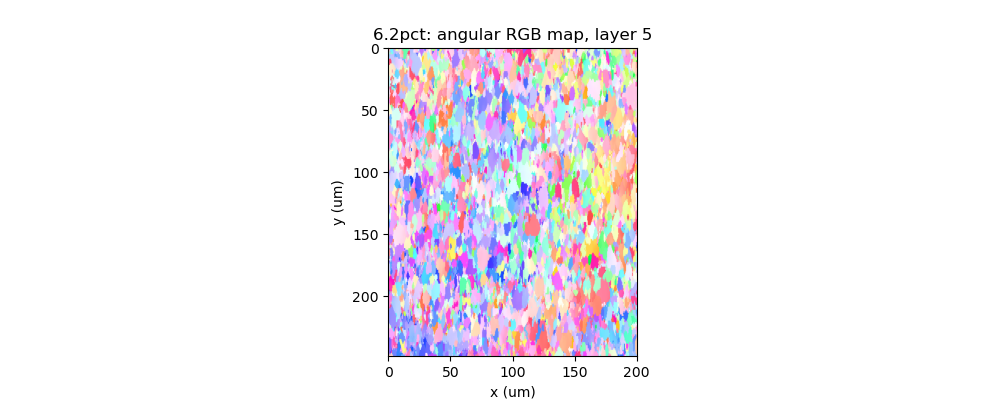

In [70]:
%matplotlib ipympl

# one fixed colour normalisation for the whole volume, so every layer is comparable
lo = np.array([np.nanmin(field[..., c]) for c in range(2)])
hi = np.array([np.nanmax(field[..., c]) for c in range(2)])
norm = np.stack([lo - 0.001 * (hi - lo), hi + 0.001 * (hi - lo)], axis=1)

rgb = np.stack([darling.transforms.rgb(field[z], norm=norm)[0] for z in range(field.shape[0])])
rgb[~mask] = 1.0                                             # outside the mask: white

dz_um, dy_um, dx_um = spacing_um
extent = [0, field.shape[2] * dx_um, field.shape[1] * dy_um, 0]

plt.figure(figsize=(10, 4))
plt.imshow(rgb[layer], extent=extent)
plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.title(f"{dataset_name}: angular RGB map, layer {layer}")
plt.show()

## 6. KAM field

In [71]:
# KAM is calculated once below with a physically isotropic 3D footprint.
# The low-memory implementation is used because the full neighbourhood array
# can require tens of gigabytes for the high-resolution grain-149 volumes.

KAM footprint shape: (3, 3, 5) | true voxels: 5
KAM median / 95th pct (deg): 0.0196 / 0.4565


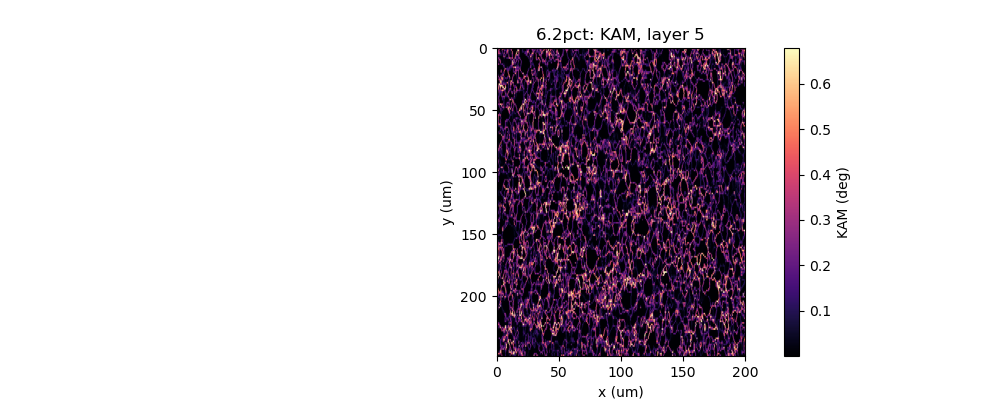

In [72]:
# physical-radius, per-channel-RMS 3D KAM
# low-memory rewrite: accumulates over the 493 true footprint voxels instead of
# materialising a (Z, Y, X, n_offsets) float64 array (that was the 88 GB alloc)
spacing_nm = VoxelSpacing(dz_um * 1e3, dy_um * 1e3, dx_um * 1e3)
kam_footprint = isotropic_physical_footprint(spacing_nm, radius_nm=kam_radius_um * 1e3, ndim=3)


def kam_lowmem(field, mask, footprint):
    f = np.where(mask[..., None], field, np.nan).astype(np.float32)
    C = f.shape[-1]

    offs = np.argwhere(footprint) - (np.array(footprint.shape) // 2)
    offs = offs[~(offs == 0).all(axis=1)]

    acc = np.zeros(f.shape[:-1], np.float32)
    cnt = np.zeros(f.shape[:-1], np.int32)

    def pair(d, n):                                   # (centre slice, neighbour slice)
        return (slice(0, n - d), slice(d, n)) if d >= 0 else (slice(-d, n), slice(0, n + d))

    for off in offs:
        a, b = zip(*[pair(int(d), n) for d, n in zip(off, f.shape[:-1])])
        d2 = np.zeros(f[a].shape[:-1], np.float32)
        for c in range(C):
            t = f[b + (c,)] - f[a + (c,)]
            d2 += t * t
        mag = np.sqrt(d2 / C)                         # per-channel RMS of the difference
        ok = np.isfinite(mag)                         # drops masked and out-of-volume neighbours
        acc[a] += np.where(ok, mag, 0.0).astype(np.float32)
        cnt[a] += ok

    out = np.divide(acc, cnt, out=np.full(acc.shape, np.nan, np.float32), where=cnt > 0)
    out[~mask] = np.nan
    return out


kam_map = kam_lowmem(field, mask, kam_footprint)

print("KAM footprint shape:", kam_footprint.shape, "| true voxels:", int(kam_footprint.sum()))
print("KAM median / 95th pct (deg): %.4f / %.4f"
      % (np.nanmedian(kam_map[mask]), np.nanpercentile(kam_map[mask], 95)))

plt.figure(figsize=(10, 4))
plt.imshow(kam_map[layer], cmap="magma", extent=extent,
           vmax=np.nanpercentile(kam_map[mask], 99))
plt.colorbar(label="KAM (deg)")
plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.title(f"{dataset_name}: KAM, layer {layer}")
plt.show()

In [73]:
# Sanity checks shared by every threshold in the sweep.
assert kam_map.shape == mask.shape
assert np.isfinite(kam_map[mask]).any()
assert np.isnan(kam_map[~mask]).all()
print("KAM is ready for", len(kam_percentiles), "threshold values.")

KAM is ready for 10 threshold values.


## 7. Flood-fill segmentation

In [74]:
voxel_volume_um3 = dz_um * dy_um * dx_um
min_voxels = max(1, int(round(minimum_volume_um3 / voxel_volume_um3)))

result, _ = disell.flood_fill_dfxm_two_stage(
    np.nan_to_num(field, nan=0.0).astype(np.float32),
    footprint=flood_footprint({"segmentation": {"flood_footprint": "inplane8_plus_z"}}),
    local_misorientation_threshold=tau_loc,
    global_threshold=tau_glob,
    footprint_tolerance=tau_fp,
    mask=mask.astype(np.uint8),
    max_iterations=max_iterations,
    min_grain_size=min_voxels,
    stagnation_tolerance=stagnation_tolerance,
    random_seed=seed,
)
markers = np.asarray(result["segmentation"], dtype=np.int32)

# KAM-guided watershed refinement of the markers
watershed_feature = watershed_feature_from_kam(kam_map, mask)
labels_floodfill = np.asarray(
    disell.region_grow_watershed(markers, mask, watershed_feature, connectivity=1),
    dtype=np.int32,
)

unlabelled = int(((labels_floodfill == 0) & mask).sum())
print("minimum volume: %.2f um3 -> %d voxels" % (minimum_volume_um3, min_voxels))
print("markers:", int((np.unique(markers) > 0).sum()))
print("final labels:", int((np.unique(labels_floodfill) > 0).sum()))
print("labelled valid fraction: %.4f" % (((labels_floodfill > 0) & mask).sum() / mask.sum()))
print("unlabelled valid voxels:", unlabelled)
print("labels outside the mask:", int((labels_floodfill[~mask] > 0).sum()))
assert unlabelled == 0, "valid mask is not completely assigned"

minimum volume: 6.00 um3 -> 24 voxels
markers: 3081
final labels: 3081
labelled valid fraction: 1.0000
unlabelled valid voxels: 0
labels outside the mask: 0


## 8. Systematic KAM-threshold sweep

Each percentile defines low-KAM connected components used as seeds. Every seed set
is grown with the same KAM-guided watershed used after multiseed flood fill, so the
comparison isolates the seed-generation method. Agreement metrics are label-invariant:
lower variation of information (VI) and higher matched overlap indicate closer partitions.

In [75]:
def segment_from_kam_percentile(percentile):
    """Create 3D low-KAM markers and grow them over the common valid mask."""
    values = kam_map[mask & np.isfinite(kam_map)]
    threshold = float(np.percentile(values, percentile))
    interior = mask & np.isfinite(kam_map) & (kam_map < threshold)
    components, _ = ndimage.label(
        interior, structure=ndimage.generate_binary_structure(mask.ndim, 1)
    )
    sizes = np.bincount(components.ravel())
    keep = np.flatnonzero(sizes >= min_voxels)
    keep = keep[keep > 0]
    markers = np.where(np.isin(components, keep), components, 0).astype(np.int32)
    labels = np.asarray(
        disell.region_grow_watershed(markers, mask, watershed_feature, connectivity=1),
        dtype=np.int32,
    )
    return threshold, markers, labels


def segmentation_summary(labels):
    """Count domains and summarize physical volume and angular RMS spread."""
    selected = mask & (labels > 0)
    lab = labels[selected]
    values = field[selected].astype(np.float64)
    n_labels = int(np.unique(lab).size)
    if not lab.size:
        return n_labels, np.nan, np.nan
    counts = np.bincount(lab)
    variance = np.zeros_like(counts, dtype=float)
    for c in range(values.shape[-1]):
        means = np.bincount(lab, weights=values[:, c], minlength=counts.size) / np.maximum(counts, 1)
        residual = values[:, c] - means[lab]
        variance += np.bincount(lab, weights=residual**2, minlength=counts.size) / np.maximum(counts, 1)
    used = counts > 0
    used[0] = False
    return n_labels, float(np.median(counts[used] * voxel_volume_um3)), float(np.median(np.sqrt(variance[used])))


kam_segmentations = {}
sweep_rows = []
for percentile in kam_percentiles:
    threshold, kam_markers, labels = segment_from_kam_percentile(float(percentile))
    kam_segmentations[float(percentile)] = labels
    n_labels, median_volume, median_rms = segmentation_summary(labels)
    sweep_rows.append(dict(
        percentile=float(percentile), threshold_deg=threshold,
        markers=int(np.unique(kam_markers[kam_markers > 0]).size), labels=n_labels,
        median_volume_um3=median_volume, median_rms_deg=median_rms,
        vi_bits=disell.variation_of_information(labels_floodfill, labels, mask=mask),
        matched_overlap=disell.matched_overlap(labels_floodfill, labels, mask=mask),
    ))

if float(display_kam_percentile) not in kam_segmentations:
    raise ValueError("display_kam_percentile must be included in kam_percentiles")
labels_kam = kam_segmentations[float(display_kam_percentile)]

header = "pct  threshold(deg)  markers  labels  median V(um3)  median RMS(deg)  VI(bits)  overlap"
print(header)
for row in sweep_rows:
    print("{percentile:3.0f}  {threshold_deg:14.5f}  {markers:7d}  {labels:6d}  "
          "{median_volume_um3:13.3f}  {median_rms_deg:15.5f}  {vi_bits:8.4f}  {matched_overlap:7.4f}".format(**row))

finite_rows = [row for row in sweep_rows if np.isfinite(row["matched_overlap"])]
if finite_rows:
    closest = max(finite_rows, key=lambda row: row["matched_overlap"])
    print("\nClosest KAM partition by matched overlap: "
          f"{closest['percentile']:g}th percentile "
          f"({closest['threshold_deg']:.5f} deg, overlap={closest['matched_overlap']:.4f}, "
          f"VI={closest['vi_bits']:.4f} bits)")

pct  threshold(deg)  markers  labels  median V(um3)  median RMS(deg)  VI(bits)  overlap
  5         0.00248      294     294        630.292          0.46675    3.7286   0.2429
 10         0.00338      533     533        341.248          0.41628    2.9867   0.3494
 15         0.00419      775     775        240.312          0.38072    2.6325   0.4166
 20         0.00501      961     961        187.488          0.36574    2.4144   0.4625
 25         0.00592     1073    1073        165.912          0.35682    2.3245   0.4815
 30         0.00696     1183    1183        140.864          0.34875    2.2600   0.4947
 35         0.00825     1263    1263        119.536          0.33867    2.2412   0.4962
 40         0.00998     1311    1311        100.192          0.33638    2.2826   0.4880
 45         0.01270     1286    1286         83.576          0.33829    2.4395   0.4559
 50         0.01961     1049    1049         71.672          0.34586    2.9762   0.3719

Closest KAM partition by matche

## 9. Threshold sensitivity and direct visual comparison

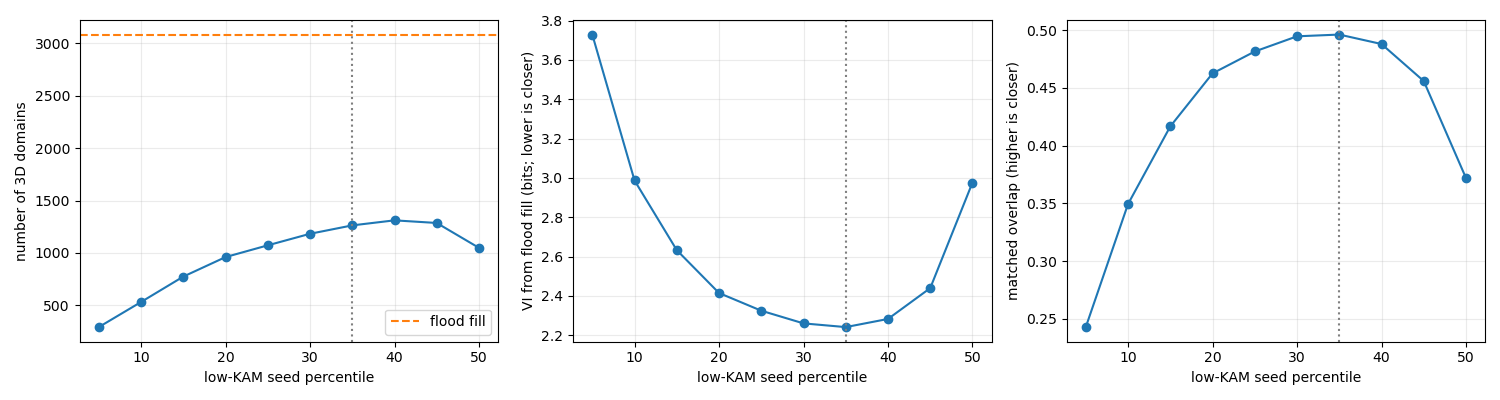

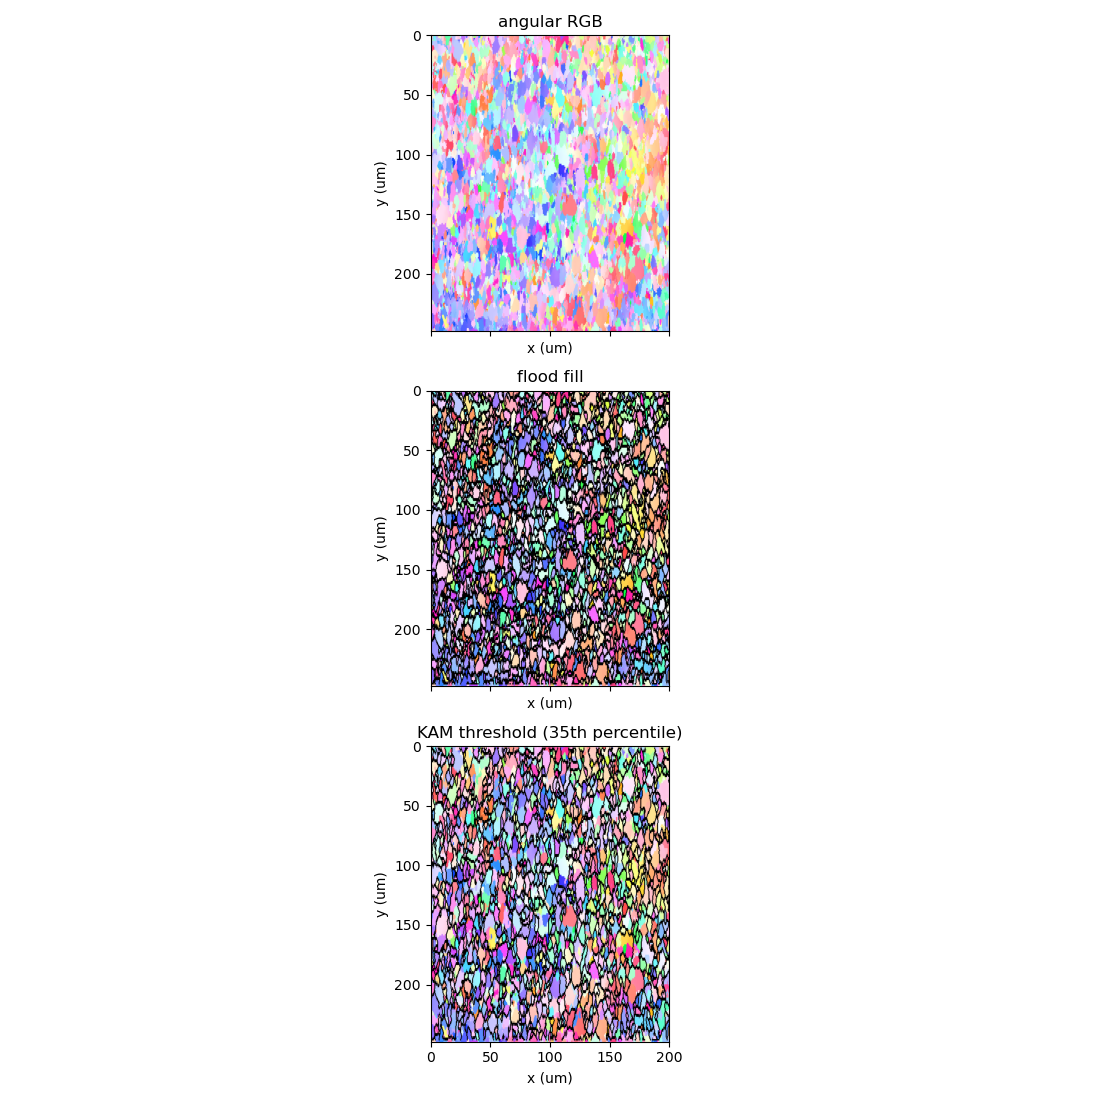

In [76]:
percentiles = np.array([row["percentile"] for row in sweep_rows])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(percentiles, [row["labels"] for row in sweep_rows], "-o")
axes[0].axhline(segmentation_summary(labels_floodfill)[0], color="C1", ls="--", label="flood fill")
axes[0].set_ylabel("number of 3D domains")
axes[0].legend()
axes[1].plot(percentiles, [row["vi_bits"] for row in sweep_rows], "-o")
axes[1].set_ylabel("VI from flood fill (bits; lower is closer)")
axes[2].plot(percentiles, [row["matched_overlap"] for row in sweep_rows], "-o")
axes[2].set_ylabel("matched overlap (higher is closer)")
for ax in axes:
    ax.axvline(display_kam_percentile, color="0.5", ls=":")
    ax.set_xlabel("low-KAM seed percentile")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

interior_mask = ndimage.binary_erosion(mask[layer])          # keeps the outer mask edge out of the boundaries
b_ff = find_boundaries(labels_floodfill[layer], mode="inner") & interior_mask
b_kam = find_boundaries(labels_kam[layer], mode="inner") & interior_mask

overlay_ff = rgb[layer].copy()
overlay_ff[b_ff] = 0.0
overlay_kam = rgb[layer].copy()
overlay_kam[b_kam] = 0.0

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True, sharey=True)
axes[0].imshow(rgb[layer], extent=extent)
axes[0].set_title("angular RGB")
axes[1].imshow(overlay_ff, extent=extent)
axes[1].set_title("flood fill")
axes[2].imshow(overlay_kam, extent=extent)
axes[2].set_title(f"KAM threshold ({display_kam_percentile:g}th percentile)")
for ax in axes:
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
fig.tight_layout()
plt.show()

## 10. Three-layer comparison

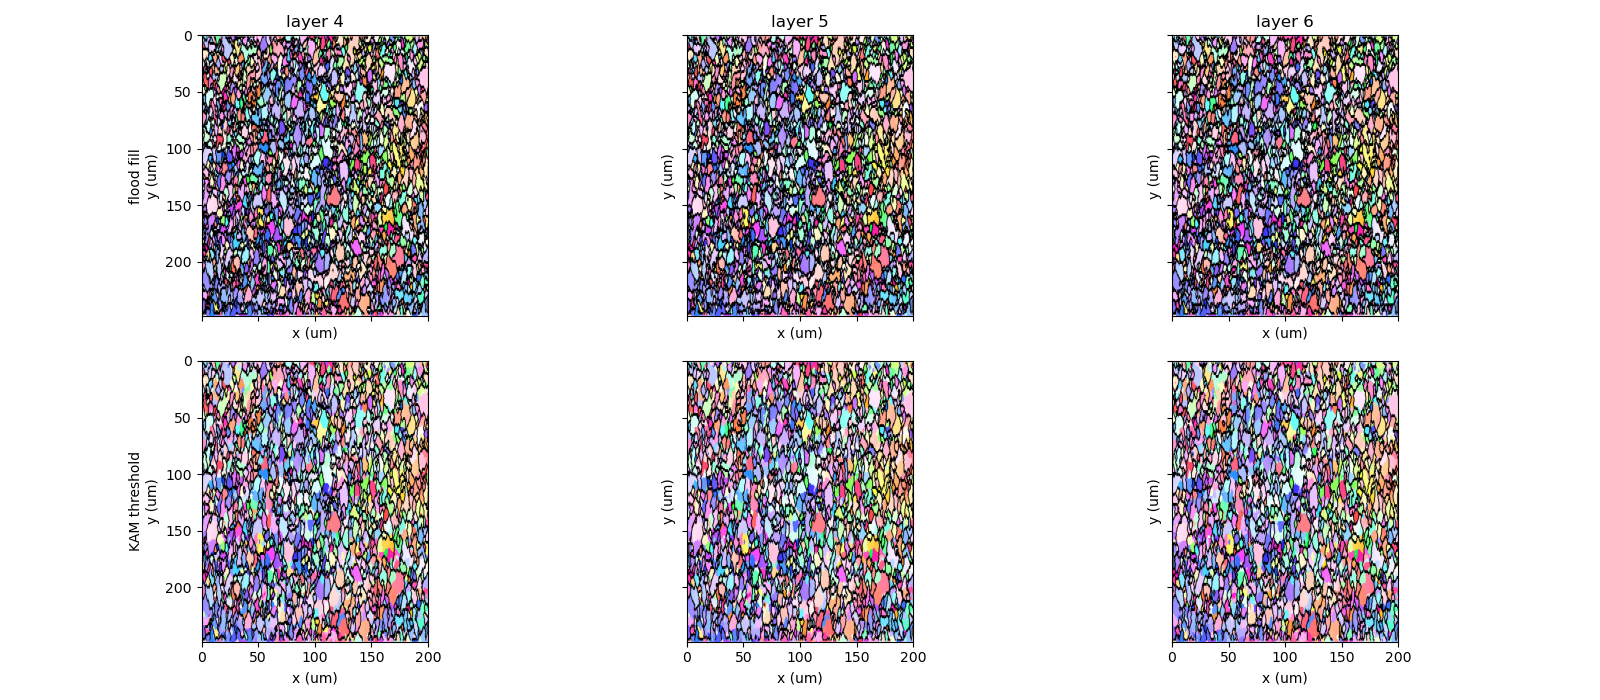

In [77]:
layers = [max(layer - 1, 0), layer, min(layer + 1, field.shape[0] - 1)]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True, sharey=True)
for j, z in enumerate(layers):
    inner = ndimage.binary_erosion(mask[z])
    for i, lab in enumerate((labels_floodfill, labels_kam)):
        img = rgb[z].copy()
        img[find_boundaries(lab[z], mode="inner") & inner] = 0.0
        axes[i, j].imshow(img, extent=extent)
        axes[i, j].set_xlabel("x (um)")
        axes[i, j].set_ylabel("y (um)")
    axes[0, j].set_title(f"layer {z}")
axes[0, 0].set_ylabel("flood fill\ny (um)")
axes[1, 0].set_ylabel("KAM threshold\ny (um)")
fig.tight_layout()
plt.show()

flood fill N=3081 | RMS med=0.1922 deg | vol med=44.1 um3 | d_eq med=4.38 um  IQR 3.40-5.83
KAM        N=1263 | RMS med=0.3387 deg | vol med=119.5 um3 | d_eq med=6.11 um  IQR 4.86-7.82


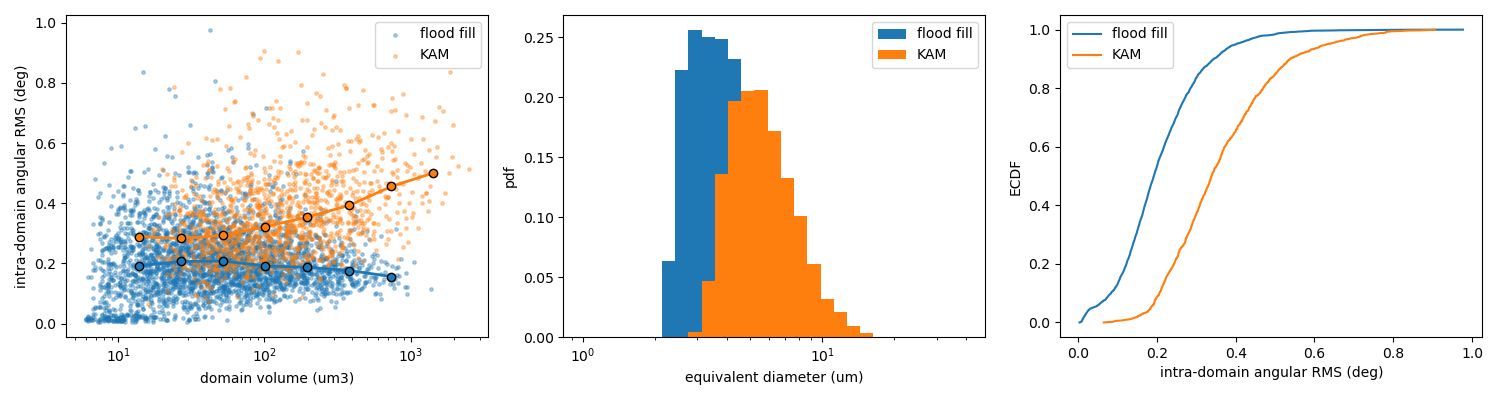

In [78]:
def spread(field, labels, mask):
    """Per-domain size (voxels) and angular RMS spread (deg), two-pass."""
    sel = mask & (labels > 0)
    lab = labels[sel]
    a = field[sel].astype(np.float64)
    nl = int(lab.max()) + 1
    n = np.bincount(lab, minlength=nl)
    var = np.zeros(nl)
    for c in range(a.shape[-1]):
        m = np.bincount(lab, weights=a[:, c], minlength=nl) / np.maximum(n, 1)
        d = a[:, c] - m[lab]
        var += np.bincount(lab, weights=d * d, minlength=nl) / np.maximum(n, 1)
    keep = n > 0
    keep[0] = False
    return n[keep], np.sqrt(var[keep])


bins = np.logspace(np.log10(10), np.log10(2000), 9)          # matched-volume bins
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for name, lab, col in [("flood fill", labels_floodfill, "C0"), ("KAM", labels_kam, "C1")]:
    n, r = spread(field, lab, mask)
    v = n * voxel_volume_um3
    d_eq = (6.0 * v / np.pi) ** (1.0 / 3.0)                   # sphere-equivalent diameter, um

    print("%-10s N=%4d | RMS med=%.4f deg | vol med=%.1f um3 | d_eq med=%.2f um  IQR %.2f-%.2f"
          % (name, n.size, np.median(r), np.median(v), np.median(d_eq),
             *np.percentile(d_eq, [25, 75])))

    ax[0].scatter(v, r, s=6, alpha=0.35, color=col, label=name)

    # median RMS per volume bin, with n>=5 required
    idx = np.digitize(v, bins)
    xs, ys = [], []
    for b in range(1, len(bins)):
        s = idx == b
        if s.sum() >= 5:
            xs.append(np.sqrt(bins[b - 1] * bins[b]))
            ys.append(np.median(r[s]))
    ax[0].plot(xs, ys, "-o", color=col, lw=2, mec="k")

    ax[1].hist(d_eq, bins=np.logspace(0, 1.6, 30), density=True, color=col, lw=1.5, label=name)
    ax[2].plot(np.sort(r), np.linspace(0, 1, r.size), color=col, label=name)

ax[0].set_xscale("log")
ax[0].set_xlabel("domain volume (um3)"); ax[0].set_ylabel("intra-domain angular RMS (deg)")
ax[1].set_xscale("log")
ax[1].set_xlabel("equivalent diameter (um)"); ax[1].set_ylabel("pdf")
ax[2].set_xlabel("intra-domain angular RMS (deg)"); ax[2].set_ylabel("ECDF")
for a_ in ax:
    a_.legend()
fig.tight_layout()
plt.show()